# Sleep Stage Classification — EOG-R · CNN-LSTM · 

## 📦 1. Imports & Seeds

In [1]:
import os, random, gc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import subprocess
subprocess.run(['pip', 'install', 'pyedflib'], check=True)
import pyedflib

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score, cohen_kappa_score,
    confusion_matrix, roc_auc_score, roc_curve, auc,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.signal import butter, filtfilt, stft
from tqdm import tqdm
import xml.etree.ElementTree as ET

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()
print(f"✅ Random seed fixed: {SEED}")
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

✅ Random seed fixed: 42
PyTorch: 2.5.1+cu121  |  CUDA: True


## 🔧 2. Signal Processing

In [ ]:
# ================================================================
# Signal Loading and Preprocessing Functions
# ================================================================

# ================================================================
# Bandpass Filter
# Remove:
# - Low-frequency drift
# - High-frequency noise
# Keep important EOG frequencies (0.3–35 Hz)
# ================================================================

def bandpass_filter(
    signal,
    fs,
    lowcut=0.3,
    highcut=35,
    order=4
):

    # ======================================
    # Nyquist Frequency
    # ======================================

    nyquist = 0.5 * fs

    # ======================================
    # Butterworth Bandpass Filter
    # ======================================

    b, a = butter(

        order,

        [
            lowcut / nyquist,
            highcut / nyquist
        ],

        btype='band'
    )

    # ======================================
    # Apply Filter
    # ======================================

    return filtfilt(

        b,
        a,
        signal

    ).astype(np.float32)


# ================================================================
# Load EOG-R Signal from EDF File
# ================================================================

def load_eog(
    file_path
):

    with pyedflib.EdfReader(file_path) as f:

        # ======================================
        # Channel Information
        # ======================================

        ch_names = f.getSignalLabels()

        fs_list = f.getSampleFrequencies()

        # ======================================
        # Find EOG-R Channel
        # ======================================

        idx = next(

            (
                i for i, ch in enumerate(ch_names)

                if ch.strip() == 'EOG-R'
            ),

            None
        )

        # Check if channel exists
        if idx is None:

            raise ValueError(
                f"EOG-R not found in: {ch_names}"
            )

        # ======================================
        # Read Signal
        # ======================================

        eog = f.readSignal(
            idx
        ).astype(np.float32)

        # Sampling frequency
        fs = int(fs_list[idx])

    # ======================================
    # Apply Bandpass Filter
    # ======================================

    return bandpass_filter(
        eog,
        fs
    ), fs


# ================================================================
# Split Signal into Epochs
# Default epoch duration = 30 seconds
# ================================================================

def create_epochs(
    signal,
    fs,
    epoch_duration=30
):

    # Samples per epoch
    samples = fs * epoch_duration

    # Number of complete epochs
    num_epochs = len(signal) // samples

    # ======================================
    # Create Epoch Array
    # ======================================

    return np.array([

        signal[
            i * samples : (i + 1) * samples
        ]

        for i in range(num_epochs)
    ])


# ================================================================
# Load Sleep Stage Labels from XML File
# ================================================================

def load_labels(
    xml_file
):

    # ======================================
    # Parse XML File
    # ======================================

    tree = ET.parse(xml_file)

    root = tree.getroot()

    labels = []

    # ============================================================
    # Read Scored Events
    # ============================================================

    for event in root.iter('ScoredEvent'):

        concept = event.find('EventConcept')

        duration = event.find('Duration')

        # Skip invalid events
        if concept is None or duration is None:

            continue

        stage = concept.text

        dur = float(duration.text)

        # ======================================
        # Ignore Non-Sleep Events
        # ======================================

        if (
            "Stage" not in stage
            and "REM" not in stage
            and "Wake" not in stage
        ):

            continue

        # Number of epochs
        n = int(round(dur / 30))

        # ======================================
        # Convert Sleep Stage to Integer Label
        # ======================================

        if 'Wake' in stage:

            lbl = 0

        elif 'Stage 1' in stage:

            lbl = 1

        elif 'Stage 2' in stage:

            lbl = 2

        elif (
            'Stage 3' in stage
            or 'Stage 4' in stage
        ):

            lbl = 3

        elif 'REM' in stage:

            lbl = 4

        else:

            continue

        # ======================================
        # Add Labels
        # ======================================

        labels.exte

## 🔬 3. Spectrogram + Normalization

In [ ]:
# ================================================================
# Signal Processing Utilities
# ================================================================

# ================================================================
# Compute Spectrogram Using STFT
# Convert one epoch from:
# - Time domain
# - To frequency domain
# ================================================================

def compute_spectrogram(
    epoch,
    fs,
    n_fft=256,
    hop=128
):

    # ======================================
    # Short-Time Fourier Transform
    # ======================================

    _, _, Zxx = stft(

        epoch,

        fs=fs,

        nperseg=n_fft,

        noverlap=n_fft - hop
    )

    # ======================================
    # Convert to Log-Magnitude Spectrogram
    # ======================================

    return np.log1p(

        np.abs(Zxx)

    ).astype(np.float32)


# ================================================================
# Convert All Epochs to Spectrograms
# ================================================================

def epochs_to_spectrograms(
    epochs,
    fs,
    n_fft=256,
    hop=128
):

    return np.array([

        compute_spectrogram(
            e,
            fs,
            n_fft,
            hop
        )

        for e in epochs
    ])


# ================================================================
# Fit StandardScaler on Training Data
# Prevents data leakage
# ================================================================

def fit_scaler_on_train(
    train_epochs
):

    scaler = StandardScaler()

    # Fit using training epochs only
    scaler.fit(

        train_epochs.reshape(-1, 1)
    )

    return scaler


# ================================================================
# Apply StandardScaler
# Normalize epochs using fitted scaler
# ================================================================

def apply_scaler(
    epochs,
    scaler
):

    # Original shape
    shape = epochs.shape

    # Normalize data
    return scaler.transform(

        epochs.reshape(-1, 1)

    ).reshape(shape).astype(np.float32)


# ================================================================
# Create Sequential Samples
# Build temporal sequences inside one subject
# ================================================================

def create_sequences_per_subject(
    epochs,
    labels,
    seq_len=10
):

    X_seq = []

    y_seq = []

    # ======================================
    # Sliding Window Sequence Creation
    # ======================================

    for i in range(

        len(epochs) - seq_len
    ):

        # Sequence of epochs
        X_seq.append(

            epochs[i:i + seq_len]
        )

        # Target label
        # Next sleep stage
        y_seq.append(

            labels[i + seq_len]
        )

    return (

        np.array(X_seq),

        np.array(y_seq)
    )

## 📂 4. Load Dataset

In [ ]:
# ================================================================
# Load All Subjects (Raw Data)
# Read:
# - EDF signal files
# - Sleep stage annotations
# Return raw epochs and labels for each subject
# ================================================================

def load_all_subjects_raw(
    data_path,
    ann_path
):

    # ======================================
    # Store Subject Data
    # ======================================

    subjects = []

    # ======================================
    # Get EDF Files
    # ======================================

    files = sorted([

        f for f in os.listdir(data_path)

        if f.endswith('.edf')
    ])

    # ============================================================
    # Process Each Subject
    # ============================================================

    for file in files:

        # EDF file path
        edf_path = os.path.join(
            data_path,
            file
        )

        # XML annotation path
        xml_path = os.path.join(
            ann_path,
            file.replace('.edf', '-nsrr.xml')
        )

        # ======================================
        # Check Annotation File
        # ======================================

        if not os.path.exists(xml_path):

            print(
                f"⚠️ Skipped (no annotation): {file}"
            )

            continue

        try:

            # ======================================
            # Load EOG Signal
            # ======================================

            signal, fs = load_eog(
                edf_path
            )

            # ======================================
            # Split Signal into Epochs
            # ======================================

            epochs = create_epochs(
                signal,
                fs
            )

            # ======================================
            # Load Sleep Stage Labels
            # ======================================

            labels = load_labels(
                xml_path
            )

            # ======================================
            # Align Epochs and Labels
            # ======================================

            min_len = min(
                len(epochs),
                len(labels)
            )

            # ======================================
            # Store Subject Data
            # ======================================

            subjects.append(

                (
                    epochs[:min_len],

                    labels[:min_len],

                    fs
                )
            )

            print(
                f"✅ Loaded: {file} "
                f"— {min_len} epochs"
            )

        except Exception as e:

            print(
                f"❌ Skipped {file}: {e}"
            )

    # ======================================
    # Final Summary
    # ======================================

    print(
        f"\nTotal subjects loaded: "
        f"{len(subjects)}"
    )

    return subjects

## ✂️ 5. Subject-level Split 

In [ ]:
# ================================================================
# Split Dataset by Subjects
# ================================================================

def split_subjects(
    subjects,
    seq_len=10,
    train_ratio=0.8,
    val_ratio=0.1,
    seed=SEED
):
    """
    Improved subject-level dataset split.

    Features
    --------
    ✅ Returns subject lists together with arrays

    ✅ No double shuffling
       Dataset is shuffled only once

    ✅ Scaler is fitted using ONLY training data
       to prevent data leakage

    Returns
    -------
    X_train, X_val, X_test

    y_train, y_val, y_test

    scaler

    train_subj, val_subj, test_subj
    """

    # ======================================
    # Shuffle Subjects
    # ======================================

    rng = np.random.default_rng(seed)

    shuffled = [

        subjects[i]

        for i in rng.permutation(
            len(subjects)
        )
    ]

    # ======================================
    # Split Sizes
    # ======================================

    n = len(shuffled)

    n_train = int(n * train_ratio)

    n_val = int(n * val_ratio)

    # ======================================
    # Subject Splits
    # ======================================

    train_subj = shuffled[:n_train]

    val_subj = shuffled[
        n_train : n_train + n_val
    ]

    test_subj = shuffled[
        n_train + n_val :
    ]

    print(
        f"Split → "
        f"Train: {len(train_subj)} | "
        f"Val: {len(val_subj)} | "
        f"Test: {len(test_subj)} subjects"
    )

    # ============================================================
    # Fit Scaler Using ONLY Training Epochs
    # Prevents data leakage
    # ============================================================

    all_train_epochs = np.concatenate(

        [s[0] for s in train_subj],

        axis=0
    )

    scaler = fit_scaler_on_train(
        all_train_epochs
    )

    print(
        f"Scaler fitted on "
        f"{len(all_train_epochs):,} "
        f"train epochs"
    )

    # ============================================================
    # Process Subject List
    # ============================================================

    def process(subj_list):

        X_all = []

        y_all = []

        for (ep_raw, lbl, fs) in subj_list:

            # ======================================
            # Normalize Epochs
            # ======================================

            ep_norm = apply_scaler(
                ep_raw,
                scaler
            )

            # ======================================
            # Create Sequences
            # ======================================

            X_seq, y_seq = create_sequences_per_subject(
                ep_norm,
                lbl,
                seq_len
            )

            X_all.append(X_seq)

            y_all.append(y_seq)

        # ======================================
        # Concatenate Subjects
        # ======================================

        return (

            np.concatenate(X_all),

            np.concatenate(y_all)
        )

    # ============================================================
    # Build Train / Validation / Test Sets
    # ============================================================

    X_train, y_train = process(train_subj)

    X_val, y_val = process(val_subj)

    X_test, y_test = process(test_subj)

    # ======================================
    # Display Dataset Sizes
    # ======================================

    print(
        f"\nTrain: {len(X_train):,} | "
        f"Val: {len(X_val):,} | "
        f"Test: {len(X_test):,} sequences"
    )

    # ======================================
    # Display Class Distribution
    # ======================================

    for name, y in [

        ('Train', y_train),

        ('Val', y_val),

        ('Test', y_test)
    ]:

        print(
            f"Class dist {name}: "
            f"{dict(zip(*np.unique(y, return_counts=True)))}"
        )

    # ============================================================
    # Return Data and Subject Lists
    # ============================================================

    return (

        X_train,
        X_val,
        X_test,

        y_train,
        y_val,
        y_test,

        scaler,

        train_subj,
        val_subj,
        test_subj
    )

## 🗃️ 6. Dataset Classes

In [ ]:
# ================================================================
# PyTorch Dataset for:
# - Raw EOG Sequences
# - Spectrogram Sequences
# - Sleep Stage Labels
# ================================================================

class SleepDatasetWithSpec(Dataset):

    def __init__(
        self,
        X_raw,
        X_spec,
        y
    ):

        # ======================================
        # Raw Signal Data
        # Shape:
        # (samples, seq_len, timesteps)
        # ======================================

        self.X_raw = torch.tensor(
            X_raw,
            dtype=torch.float32
        )

        # ======================================
        # Spectrogram Data
        # Shape:
        # (samples, seq_len, freq, width)
        # ======================================

        self.X_spec = torch.tensor(
            X_spec,
            dtype=torch.float32
        )

        # ======================================
        # Sleep Stage Labels
        # ======================================

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    # ============================================================
    # Dataset Length
    # ============================================================

    def __len__(self):

        return len(self.y)

    # ============================================================
    # Get One Sample
    # ============================================================

    def __getitem__(
        self,
        idx
    ):

        return (

            self.X_raw[idx],

            self.X_spec[idx],

            self.y[idx]
        )

## 🔬 7. Build Spectrogram Sequences

In [ ]:
# ================================================================
# Build Raw Signal + Spectrogram Dataset
# ================================================================

def build_spec_dataset(
    subjects_list,
    scaler,
    seq_len,
    fs,
    n_fft=256,
    hop=128
):
    """
    Build dataset using:
    - Raw EOG signals
    - Spectrogram representations

    Notes
    -----
    ✅ Uses the same subject split directly
       from split_subjects()

    ✅ No reshuffling is performed

    ✅ Train / Validation / Test consistency
       is guaranteed
    """

    # ======================================
    # Store Final Data
    # ======================================

    X_raw_all = []

    X_spec_all = []

    y_all = []

    # ============================================================
    # Process Each Subject
    # ============================================================

    for (ep_raw, lbl, _) in subjects_list:

        # ======================================
        # Normalize Raw Epochs
        # ======================================

        ep_norm = apply_scaler(
            ep_raw,
            scaler
        )

        # ======================================
        # Generate Spectrograms
        # ======================================

        specs = epochs_to_spectrograms(
            ep_norm,
            fs,
            n_fft,
            hop
        )

        # ======================================
        # Create Sequential Raw Data
        # ======================================

        X_seq, y_seq = create_sequences_per_subject(
            ep_norm,
            lbl,
            seq_len
        )

        # ======================================
        # Create Sequential Spectrogram Data
        # ======================================

        S_seq = np.array([

            specs[i:i + seq_len]

            for i in range(
                len(ep_norm) - seq_len
            )
        ])

        # ======================================
        # Store Subject Data
        # ======================================

        X_raw_all.append(X_seq)

        X_spec_all.append(S_seq)

        y_all.append(y_seq)

    # ============================================================
    # Concatenate All Subjects
    # ============================================================

    return (

        np.concatenate(X_raw_all),

        np.concatenate(X_spec_all),

        np.concatenate(y_all)
    )

## 🧠 8. Model: CNN + SpectrogramCNN + Bi-LSTM + Attention

In [ ]:
# ================================================================
# Sleep Staging Model
# CNN + Spectrogram CNN + Bi-LSTM + Attention
# ================================================================

# ================================================================
# 1D CNN Encoder for Raw EOG Signal
# Extract temporal features from raw epochs
# ================================================================

class CNNEncoder(nn.Module):

    def __init__(
        self,
        out_dim=128
    ):

        super().__init__()

        self.net = nn.Sequential(

            # ======================================
            # Block 1
            # ======================================

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(4),

            nn.Dropout(0.2),

            # ======================================
            # Block 2
            # ======================================

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(4),

            nn.Dropout(0.2),

            # ======================================
            # Block 3
            # ======================================

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Dropout(0.2),

            # ======================================
            # Output Block
            # ======================================

            nn.Conv1d(
                128,
                out_dim,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(out_dim),

            nn.ReLU(),

            # Global average pooling
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):

        # Output shape:
        # (batch, out_dim)
        return self.net(x).squeeze(-1)


# ================================================================
# 2D CNN for Spectrogram Features
# Extract frequency-domain information
# ================================================================

class SpectrogramCNN(nn.Module):

    def __init__(
        self,
        out_dim=64
    ):

        super().__init__()

        self.net = nn.Sequential(

            # ======================================
            # Block 1
            # ======================================

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # ======================================
            # Block 2
            # ======================================

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # ======================================
            # Output Block
            # ======================================

            nn.Conv2d(
                32,
                out_dim,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_dim),

            nn.ReLU(),

            # Global average pooling
            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x):

        # Output shape:
        # (batch, out_dim)
        return self.net(x).view(x.size(0), -1)


# ================================================================
# Temporal Attention Layer
# Learn important epochs in the sequence
# ================================================================

class TemporalAttention(nn.Module):

    def __init__(
        self,
        hidden_dim
    ):

        super().__init__()

        self.attn = nn.Linear(
            hidden_dim,
            1
        )

    def forward(
        self,
        lstm_out
    ):

        # Attention weights
        w = torch.softmax(
            self.attn(lstm_out),
            dim=1
        )

        # Weighted context vector
        return (
            w * lstm_out
        ).sum(dim=1)


# ================================================================
# Complete Sleep Staging Model
# Raw Signal + Spectrogram Features
# ================================================================

class SleepModel(nn.Module):

    def __init__(
        self,
        cnn_out=128,
        spec_out=64,
        lstm_hidden=256,
        lstm_layers=2,
        num_classes=5,
        dropout=0.3
    ):

        super().__init__()

        # ======================================
        # Feature Extractors
        # ======================================

        # Raw EOG encoder
        self.cnn = CNNEncoder(
            out_dim=cnn_out
        )

        # Spectrogram encoder
        self.spec_cnn = SpectrogramCNN(
            out_dim=spec_out
        )

        # Combined feature size
        combined = cnn_out + spec_out

        # ======================================
        # Bi-LSTM Layer
        # Learn temporal dependencies
        # ======================================

        self.lstm = nn.LSTM(

            input_size=combined,

            hidden_size=lstm_hidden,

            num_layers=lstm_layers,

            batch_first=True,

            dropout=dropout,

            bidirectional=True
        )

        # ======================================
        # Temporal Attention
        # ======================================

        self.attention = TemporalAttention(
            lstm_hidden * 2
        )

        # ======================================
        # Classification Head
        # ======================================

        self.classifier = nn.Sequential(

            nn.Linear(
                lstm_hidden * 2,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                num_classes
            ),
        )

    # ============================================================
    # Forward Pass
    # ============================================================

    def forward(
        self,
        x_raw,
        x_spec
    ):

        # ======================================
        # Input Shapes
        # ======================================

        # x_raw:
        # (Batch, Seq, Time)

        B, S, T = x_raw.shape

        # x_spec:
        # (Batch, Seq, Freq, Width)

        _, _, F, W = x_spec.shape

        # ======================================
        # Raw Signal Features
        # ======================================

        r = self.cnn(

            x_raw.view(
                B * S,
                1,
                T
            )

        ).view(B, S, -1)

        # ======================================
        # Spectrogram Features
        # ======================================

        s = self.spec_cnn(

            x_spec.view(
                B * S,
                1,
                F,
                W
            )

        ).view(B, S, -1)

        # ======================================
        # Combine Features
        # ======================================

        x = torch.cat(
            [r, s],
            dim=-1
        )

        # ======================================
        # Bi-LSTM
        # ======================================

        lstm_out, _ = self.lstm(x)

        # ======================================
        # Attention Layer
        # ======================================

        context = self.attention(
            lstm_out
        )

        # ======================================
        # Final Classification
        # ======================================

        return self.classifier(context)

## 🏋️ 9. Training Function

In [ ]:
# ================================================================
# Train the Sleep Staging Model
# ================================================================

def train_model(
    model,
    train_loader,
    val_loader,
    weights,
    epochs=30,
    save_path='best_model.pth',
    patience=7
):
    """
    Improved training function:

    ✅ Early stopping based on Macro F1-score
    ✅ ReduceLROnPlateau monitors validation F1
    ✅ Validation F1 is recorded every epoch
    """

    # ======================================
    # Device Setup
    # ======================================

    device = torch.device(
        'cuda'
        if torch.cuda.is_available()
        else 'cpu'
    )

    print('Using device:', device)

    model.to(device)

    # ======================================
    # Optimizer
    # ======================================

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    # ======================================
    # Learning Rate Scheduler
    # mode='max' because higher F1 is better
    # ======================================

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        patience=3,
        factor=0.5,
        verbose=True
    )

    # ======================================
    # Loss Function
    # ======================================

    criterion = nn.CrossEntropyLoss(
        weight=weights.to(device)
    )

    # ======================================
    # Training History
    # ======================================

    best_f1 = 0.0

    patience_counter = 0

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    val_f1s = []

    # ============================================================
    # Training Loop
    # ============================================================

    for epoch in range(epochs):

        # ========================================================
        # TRAINING
        # ========================================================

        model.train()

        tl = 0

        correct = 0

        total = 0

        for X_raw, X_spec, y in tqdm(
            train_loader,
            desc=f'Epoch {epoch+1}/{epochs}'
        ):

            # Move data to device
            X_raw = X_raw.to(device)

            X_spec = X_spec.to(device)

            y = y.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            out = model(
                X_raw,
                X_spec
            )

            # Compute loss
            loss = criterion(
                out,
                y
            )

            # Backpropagation
            loss.backward()

            # Prevent gradient explosion
            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            # Update weights
            optimizer.step()

            # Training statistics
            tl += loss.item()

            correct += (
                out.argmax(1) == y
            ).sum().item()

            total += y.size(0)

        # Average training results
        train_loss = tl / len(train_loader)

        train_acc = correct / total

        # ========================================================
        # VALIDATION
        # ========================================================

        model.eval()

        vl = 0

        correct = 0

        total = 0

        all_preds = []

        all_labels = []

        with torch.no_grad():

            for X_raw, X_spec, y in val_loader:

                # Move data to device
                X_raw = X_raw.to(device)

                X_spec = X_spec.to(device)

                y = y.to(device)

                # Forward pass
                out = model(
                    X_raw,
                    X_spec
                )

                # Compute loss
                loss = criterion(
                    out,
                    y
                )

                # Validation statistics
                vl += loss.item()

                correct += (
                    out.argmax(1) == y
                ).sum().item()

                total += y.size(0)

                all_preds.extend(
                    out.argmax(1).cpu().numpy()
                )

                all_labels.extend(
                    y.cpu().numpy()
                )

        # Average validation results
        val_loss = vl / len(val_loader)

        val_acc = correct / total

        # ======================================
        # Validation Macro F1-score
        # ======================================

        val_f1 = f1_score(
            all_labels,
            all_preds,
            average='macro',
            zero_division=0
        )

        # ======================================
        # Scheduler Step
        # Based on validation F1-score
        # ======================================

        scheduler.step(val_f1)

        # ======================================
        # Save Training History
        # ======================================

        train_losses.append(train_loss)

        val_losses.append(val_loss)

        train_accs.append(train_acc)

        val_accs.append(val_acc)

        val_f1s.append(val_f1)

        # ======================================
        # Print Epoch Results
        # ======================================

        print(
            f'Epoch {epoch+1:02d}: '
            f'Train L={train_loss:.4f} '
            f'Acc={train_acc:.4f}'
            f' | Val L={val_loss:.4f} '
            f'Acc={val_acc:.4f} '
            f'F1={val_f1:.4f}'
        )

        # ======================================
        # Save Best Model
        # ======================================

        if val_f1 > best_f1:

            best_f1 = val_f1

            patience_counter = 0

            torch.save(
                model.state_dict(),
                save_path
            )

            print(
                f'✅ Best F1={best_f1:.4f} '
                f'→ saved: {save_path}'
            )

        else:

            patience_counter += 1

            # Early stopping
            if patience_counter >= patience:

                print(
                    f'⏹️ Early stopping at epoch '
                    f'{epoch+1} '
                    f'(best F1={best_f1:.4f})'
                )

                break

    # ============================================================
    # Return Training History
    # ============================================================

    return (
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        val_f1s
    )

## 📊 10. Evaluation

In [10]:
def evaluate(model, test_loader, save_path='best_model.pth', num_classes=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    model.to(device).eval()

    preds_l, labels_l, probs_l = [], [], []
    with torch.no_grad():
        for X_raw, X_spec, y in test_loader:
            X_raw, X_spec = X_raw.to(device), X_spec.to(device)
            out  = model(X_raw, X_spec)
            prob = torch.softmax(out, 1).cpu().numpy()
            p    = out.argmax(1).cpu().numpy()
            preds_l.extend(p); labels_l.extend(y.numpy()); probs_l.append(prob)

    probs  = np.concatenate(probs_l)
    labels = np.array(labels_l)
    preds  = np.array(preds_l)
    names  = ['Wake', 'Stage 1', 'Stage 2', 'Stage 3/4', 'REM']

    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(labels, preds, target_names=names, zero_division=0))
    print(f"Macro F1    : {f1_score(labels, preds, average='macro', zero_division=0):.4f}")
    print(f"Cohen Kappa : {cohen_kappa_score(labels, preds):.4f}")

    print("\n" + "-"*40)
    print("AUC-ROC per class (One-vs-Rest):")
    auc_scores = []
    for cls in range(num_classes):
        if cls in labels:
            a = roc_auc_score((labels == cls).astype(int), probs[:, cls])
            print(f"  {names[cls]:<12}: {a:.4f}")
            auc_scores.append(a)
        else:
            print(f"  {names[cls]:<12}: N/A")
    if auc_scores:
        print(f"  {'Macro AUC':<12}: {np.mean(auc_scores):.4f}")

    return preds.tolist(), labels_l, probs

## 📈 11. Visualization Functions

In [11]:
def plot_results(train_losses, val_losses, train_accs, val_accs, val_f1s=None,
                save_path='training_curves.png'):
    ncols = 3 if val_f1s else 2
    fig, axes = plt.subplots(1, ncols, figsize=(7*ncols, 5))

    axes[0].plot(train_losses, color='#2196F3', lw=2, label='Train Loss')
    axes[0].plot(val_losses,   color='#F44336', lw=2, label='Val Loss')
    axes[0].set(title='Loss Curve', xlabel='Epoch', ylabel='Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(train_accs, color='#4CAF50', lw=2, label='Train Acc')
    axes[1].plot(val_accs,   color='#FF9800', lw=2, label='Val Acc')
    axes[1].set(title='Accuracy Curve', xlabel='Epoch', ylabel='Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    if val_f1s and ncols == 3:
        axes[2].plot(val_f1s, color='#9C27B0', lw=2, label='Val Macro F1')
        axes[2].axhline(max(val_f1s), color='#9C27B0', ls='--', alpha=0.5,
                        label=f'Best F1={max(val_f1s):.4f}')
        axes[2].set(title='Val Macro F1 (Early Stopping)', xlabel='Epoch', ylabel='F1')
        axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle('Training & Validation Curves', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f'✅ Saved: {save_path}')

def plot_confusion_matrix(labels, preds, save_path='confusion_matrix.png'):
    names   = ['Wake', 'Stage 1', 'Stage 2', 'Stage 3/4', 'REM']
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=axes[0], linewidths=0.5)
    axes[0].set(title='Confusion Matrix — Raw Counts', xlabel='Predicted', ylabel='True')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=names, yticklabels=names,
                ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
    axes[1].set(title='Confusion Matrix — Normalized (Recall)', xlabel='Predicted', ylabel='True')
    plt.suptitle('Sleep Stage Classification Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f'✅ Saved: {save_path}')

def plot_roc_curves(labels, probs, save_path='roc_curves.png'):
    names    = ['Wake', 'Stage 1', 'Stage 2', 'Stage 3/4', 'REM']
    colors   = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB', '#9B59B6']
    labels_a = np.array(labels)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    auc_vals, avail_names, avail_colors = [], [], []
    for i, (name, color) in enumerate(zip(names, colors)):
        if i not in labels_a: continue
        fpr, tpr, _ = roc_curve((labels_a == i).astype(int), probs[:, i])
        auc_val = auc(fpr, tpr)
        auc_vals.append(auc_val)
        avail_names.append(name); avail_colors.append(color)
        axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.3f})')
    axes[0].plot([0,1],[0,1],'k--', lw=1)
    axes[0].set(title='ROC Curves — One-vs-Rest',
                xlabel='False Positive Rate', ylabel='True Positive Rate')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
    bars = axes[1].bar(avail_names, auc_vals, color=avail_colors,
                       alpha=0.8, edgecolor='black', lw=0.5)
    axes[1].axhline(np.mean(auc_vals), color='black', ls='--',
                    label=f'Macro AUC = {np.mean(auc_vals):.3f}')
    for bar, val in zip(bars, auc_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1].set(title='AUC per Sleep Stage', xlabel='Stage', ylabel='AUC', ylim=(0, 1.08))
    axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
    plt.suptitle('AUC-ROC Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f'✅ Saved: {save_path}')

def plot_hypnogram(preds, labels, subject_id=None, save_path='hypnogram.png'):
    preds   = np.array(preds)
    labels  = np.array(labels)
    snames  = ['Wake', 'N1', 'N2', 'N3', 'REM']
    n       = len(labels)
    t_hr    = np.arange(n) * 30 / 3600
    acc   = accuracy_score(labels, preds) * 100
    f1    = f1_score(labels, preds, average='macro', zero_division=0) * 100
    kappa = cohen_kappa_score(labels, preds)
    bg = {0:'#E8F4FD', 1:'#FFF8E1', 2:'#E8F5E9', 3:'#EDE7F6', 4:'#FCE4EC'}
    fig, axes = plt.subplots(3, 1, figsize=(18, 11),
                             gridspec_kw={'height_ratios':[3,3,1.2]}, facecolor='white')
    fig.subplots_adjust(hspace=0.38)
    sfx = f' — {subject_id}' if subject_id else ''
    fig.suptitle(f'Hypnogram: Sleep Stage Classification{sfx}\n'
                 f'Acc: {acc:.1f}%  |  Macro F1: {f1:.1f}%  |  Cohen κ: {kappa:.3f}',
                 fontsize=14, fontweight='bold', y=0.99)
    def draw(ax, stages, color, title):
        for i in range(n - 1):
            ax.axvspan(t_hr[i], t_hr[i+1], facecolor=bg[stages[i]], alpha=0.40, linewidth=0)
        ax.step(t_hr, stages, where='post', color=color, lw=1.8)
        ax.set_yticks([0,1,2,3,4]); ax.set_yticklabels(snames, fontsize=11)
        ax.invert_yaxis()
        ax.set_xlim(0, t_hr[-1]); ax.set_ylim(-0.5, 4.5)
        ax.set_xlabel('Time (hours)', fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold', loc='left', pad=6)
        ax.grid(axis='x', ls='--', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
        for yy in [0.5, 1.5, 2.5, 3.5]:
            ax.axhline(yy, color='gray', lw=0.4, alpha=0.4)
    draw(axes[0], labels, '#D85A30', 'True Sleep Stages  (Expert / Ground Truth)')
    draw(axes[1], preds,  '#185FA5', 'Predicted  (CNN + Bi-LSTM + Attention)')
    ax3   = axes[2]
    agree = (preds == labels).astype(int)
    w     = 30 / 3600
    ax3.bar(t_hr, agree,     width=w, color='#2E7D32', alpha=0.75, label='Correct')
    ax3.bar(t_hr, 1 - agree, width=w, color='#C62828', alpha=0.50, label='Mismatch')
    ax3.set_xlim(0, t_hr[-1]); ax3.set_ylim(0, 1.35); ax3.set_yticks([])
    ax3.set_xlabel('Time (hours)', fontsize=10)
    ax3.set_title('Epoch-level Agreement  (green=correct, red=mismatch)',
                  fontsize=11, fontweight='bold', loc='left', pad=6)
    ax3.spines[['top','right','left']].set_visible(False)
    ax3.text(0.99, 1.15, f'{agree.mean()*100:.1f}% correct',
             transform=ax3.transAxes, ha='right', va='top',
             fontsize=10, color='#2E7D32', fontweight='bold')
    from matplotlib.patches import Patch as P
    patches  = [P(facecolor=bg[i], alpha=0.7, label=nm) for i, nm in enumerate(snames)]
    patches += [mpatches.Patch(color='#D85A30', label='True'),
                mpatches.Patch(color='#185FA5', label='Predicted')]
    fig.legend(handles=patches, loc='upper right',
               bbox_to_anchor=(1.0, 0.97), fontsize=9,
               framealpha=0.85, title='Stages & Lines')
    plt.tight_layout(rect=[0, 0, 0.88, 0.96])
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'✅ Saved: {save_path}')
    plt.show()

## 🔄 12. K-Fold Cross-Validation

In [12]:
def kfold_cross_validation(subjects, k=5, seq_len=10, n_epochs=20,
                           batch_size=32, seed=SEED):
    rng      = np.random.default_rng(seed)
    subjects = [subjects[i] for i in rng.permutation(len(subjects))]
    fs       = subjects[0][2]
    fold_size = max(1, len(subjects) // k)
    results   = []
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    for fold in range(k):
        print(f"\n{'='*55}\n  FOLD {fold+1}/{k}\n{'='*55}")
        test_idx  = list(range(fold * fold_size,
                               min((fold+1) * fold_size, len(subjects))))
        train_idx = [i for i in range(len(subjects)) if i not in test_idx]
        train_s   = [subjects[i] for i in train_idx]
        test_s    = [subjects[i] for i in test_idx]
        print(f"Train: {len(train_s)} | Test: {len(test_s)} subjects")
        scaler = fit_scaler_on_train(np.concatenate([s[0] for s in train_s]))
        Xtr, Str, ytr = build_spec_dataset(train_s, scaler, seq_len, fs)
        Xte, Ste, yte = build_spec_dataset(test_s,  scaler, seq_len, fs)
        cls  = np.unique(ytr)
        w    = compute_class_weight('balanced', classes=cls, y=ytr)
        wt   = torch.tensor(w, dtype=torch.float32)
        tr_l = DataLoader(SleepDatasetWithSpec(Xtr, Str, ytr), batch_size, shuffle=True,  num_workers=0)
        te_l = DataLoader(SleepDatasetWithSpec(Xte, Ste, yte), batch_size, shuffle=False, num_workers=0)
        set_seed(seed + fold)
        model = SleepModel()
        spath = f'fold_{fold+1}_best.pth'
        train_model(model, tr_l, te_l, wt, epochs=n_epochs, save_path=spath)
        preds, lbls, probs = evaluate(model, te_l, save_path=spath)
        f1    = f1_score(lbls, preds, average='macro', zero_division=0)
        kappa = cohen_kappa_score(lbls, preds)
        try:
            au = roc_auc_score(np.eye(5)[np.array(lbls)], probs, multi_class='ovr', average='macro')
        except Exception:
            au = float('nan')
        results.append({'fold': fold+1, 'f1': f1, 'kappa': kappa, 'auc': au})
        print(f"Fold {fold+1} → F1={f1:.4f} | Kappa={kappa:.4f} | AUC={au:.4f}")
    print(f"\n{'='*55}\nCROSS-VALIDATION SUMMARY\n{'='*55}")
    f1s = [r['f1'] for r in results]
    ks  = [r['kappa'] for r in results]
    aus = [r['auc'] for r in results if not np.isnan(r['auc'])]
    print(f"Macro F1    : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"Cohen Kappa : {np.mean(ks):.4f} ± {np.std(ks):.4f}")
    if aus: print(f"Macro AUC   : {np.mean(aus):.4f} ± {np.std(aus):.4f}")
    return results

## 🚀 13. Main Execution — Subject-level Split

In [13]:
# ─── Config ──────────────────────────────────────────────────
data_path = r"C:\Users\Laptop\Desktop\Project\Signals"
ann_path  = r"C:\Users\Laptop\Desktop\Project\Annotations"
SEQ_LEN   = 10
N_FFT     = 256
HOP       = 128

In [14]:
# Step 1 — Load raw subjects
subjects = load_all_subjects_raw(data_path, ann_path)
gc.collect()

✅ Loaded: mesa-sleep-0001.edf — 1439 epochs
✅ Loaded: mesa-sleep-0002.edf — 1319 epochs
✅ Loaded: mesa-sleep-0006.edf — 1079 epochs
✅ Loaded: mesa-sleep-0010.edf — 1199 epochs
✅ Loaded: mesa-sleep-0012.edf — 1427 epochs
✅ Loaded: mesa-sleep-0014.edf — 1679 epochs
✅ Loaded: mesa-sleep-0016.edf — 1199 epochs
✅ Loaded: mesa-sleep-0021.edf — 1079 epochs
✅ Loaded: mesa-sleep-0027.edf — 1199 epochs
✅ Loaded: mesa-sleep-0028.edf — 1139 epochs

Total subjects loaded: 10


0

In [15]:
# Step 2 — Subject-level split 80/10/10 (FIXED — single shuffle, returns subject lists)
(X_train, X_val, X_test,
 y_train, y_val,  y_test,
 scaler,
 train_subj, val_subj, test_subj) = split_subjects(
    subjects, seq_len=SEQ_LEN, train_ratio=0.8, val_ratio=0.1
)
fs_global = subjects[0][2]
gc.collect()

Split → Train: 8 | Val: 1 | Test: 1 subjects
Scaler fitted on 10,240 train epochs

Train: 10,160 | Val: 1,309 | Test: 1,189 sequences
Class dist Train: {np.int64(0): np.int64(4730), np.int64(1): np.int64(755), np.int64(2): np.int64(3105), np.int64(3): np.int64(679), np.int64(4): np.int64(891)}
Class dist Val: {np.int64(0): np.int64(561), np.int64(1): np.int64(49), np.int64(2): np.int64(362), np.int64(3): np.int64(156), np.int64(4): np.int64(181)}
Class dist Test: {np.int64(0): np.int64(205), np.int64(1): np.int64(130), np.int64(2): np.int64(641), np.int64(3): np.int64(24), np.int64(4): np.int64(189)}


0

In [16]:
# Step 3 — Build Spectrogram Sequences (FIXED — يستخدم نفس الـ lists من Step 2)
print("Building spectrogram sequences...")
Xtr_r, Xtr_s, ytr = build_spec_dataset(train_subj, scaler, SEQ_LEN, fs_global, N_FFT, HOP)
Xvl_r, Xvl_s, yvl = build_spec_dataset(val_subj,   scaler, SEQ_LEN, fs_global, N_FFT, HOP)
Xte_r, Xte_s, yte = build_spec_dataset(test_subj,  scaler, SEQ_LEN, fs_global, N_FFT, HOP)
print(f"Spec shape (train): {Xtr_s.shape}")
gc.collect()

Building spectrogram sequences...
Spec shape (train): (10160, 10, 129, 61)


0

In [17]:
# Step 4 — Class weights (smoothed — لتقليل dominance الـ Stage 3/4)
classes    = np.unique(ytr)
weights_np = compute_class_weight('balanced', classes=classes, y=ytr)
# ✅ Smoothing: نقلل الـ weight بنسبة 30% عشان نمنع overcompensation
weights_np = np.sqrt(weights_np)          # square-root smoothing
weights_np = weights_np / weights_np.sum() * len(weights_np)   # re-normalize
weights    = torch.tensor(weights_np, dtype=torch.float32)
print('Class weights (smoothed):', dict(zip(classes, weights_np.round(3))))

Class weights (smoothed): {np.int64(0): np.float64(0.516), np.int64(1): np.float64(1.293), np.int64(2): np.float64(0.637), np.int64(3): np.float64(1.363), np.int64(4): np.float64(1.19)}


In [18]:
# Step 5 — DataLoaders
train_loader = DataLoader(SleepDatasetWithSpec(Xtr_r, Xtr_s, ytr),
                          batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(SleepDatasetWithSpec(Xvl_r, Xvl_s, yvl),
                          batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(SleepDatasetWithSpec(Xte_r, Xte_s, yte),
                          batch_size=32, shuffle=False, num_workers=0)
print('Train batches:', len(train_loader))
sample = next(iter(train_loader))
print('Raw input shape :', sample[0].shape)
print('Spec input shape:', sample[1].shape)

Train batches: 318
Raw input shape : torch.Size([32, 10, 7680])
Spec input shape: torch.Size([32, 10, 129, 61])


In [19]:
# Step 6 — Init Model
set_seed()
model = SleepModel(cnn_out=128, spec_out=64, lstm_hidden=256,
                   lstm_layers=2, num_classes=5, dropout=0.3)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

Total trainable parameters: 2,674,150


In [20]:
# Step 7 — Train (Early stopping على macro F1)
train_losses, val_losses, train_accs, val_accs, val_f1s = train_model(
    model, train_loader, val_loader, weights=weights,
    epochs=30, save_path='best_model_A.pth', patience=7
)

Using device: cuda


C:\ProgramData\anaconda3\envs\torch_gpu\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/30: 100%|██████████| 318/318 [01:18<00:00,  4.03it/s]


Epoch 01: Train L=1.1230 Acc=0.6662 | Val L=0.7730 Acc=0.6898 F1=0.5144
  ✅ Best F1=0.5144 → saved: best_model_A.pth


Epoch 2/30: 100%|██████████| 318/318 [01:10<00:00,  4.53it/s]


Epoch 02: Train L=0.9098 Acc=0.7068 | Val L=0.8915 Acc=0.7166 F1=0.5206
  ✅ Best F1=0.5206 → saved: best_model_A.pth


...

Epoch 15: Train L=0.5180 Acc=0.8270 | Val L=1.7082 Acc=0.5393 F1=0.3799


Epoch 16/30: 100%|██████████| 318/318 [01:06<00:00,  4.81it/s]


Epoch 16: Train L=0.5140 Acc=0.8239 | Val L=0.8528 Acc=0.6578 F1=0.5592


Epoch 17/30: 100%|██████████| 318/318 [01:06<00:00,  4.80it/s]


Epoch 17: Train L=0.5151 Acc=0.8315 | Val L=2.0263 Acc=0.5309 F1=0.3739
⏹️  Early stopping at epoch 17 (best F1=0.6377)


In [21]:
# Step 8 — Evaluate
preds, labels, probs = evaluate(model, test_loader, save_path='best_model_A.pth')


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Wake       0.93      0.87      0.90       205
     Stage 1       0.38      0.44      0.41       130
     Stage 2       0.80      0.61      0.69       641
   Stage 3/4       0.11      1.00      0.19        24
         REM       0.98      0.68      0.80       189

    accuracy                           0.66      1189
   macro avg       0.64      0.72      0.60      1189
weighted avg       0.79      0.66      0.71      1189

Macro F1    : 0.5999
Cohen Kappa : 0.5199

----------------------------------------
AUC-ROC per class (One-vs-Rest):
  Wake        : 0.9670
  Stage 1     : 0.8591
  Stage 2     : 0.8203
  Stage 3/4   : 0.9571
  REM         : 0.9496
  Macro AUC   : 0.9106


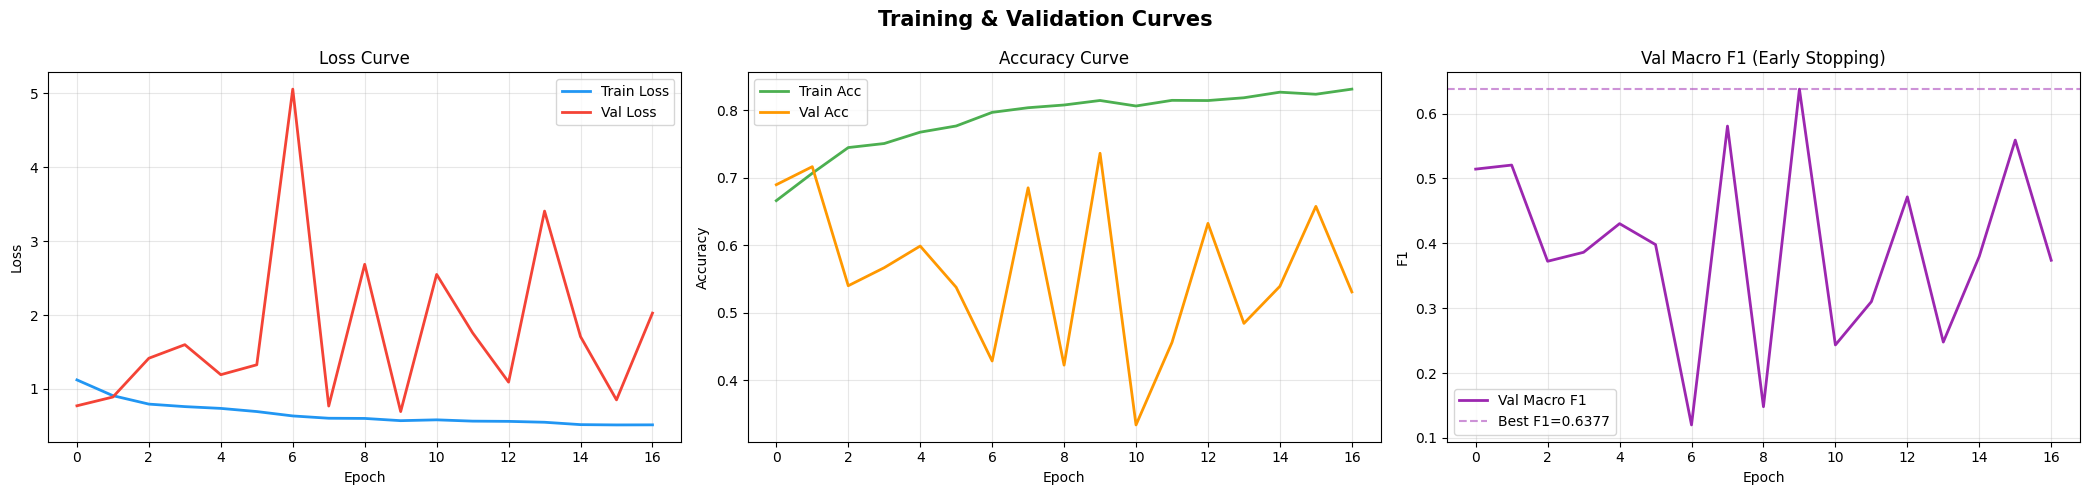

✅ Saved: A_training_curves.png


In [ ]:
# Step 9 — Training Curves (F1 curve)
plot_results(train_losses, val_losses, train_accs, val_accs, val_f1s,
             save_path='A_training_curves.png')

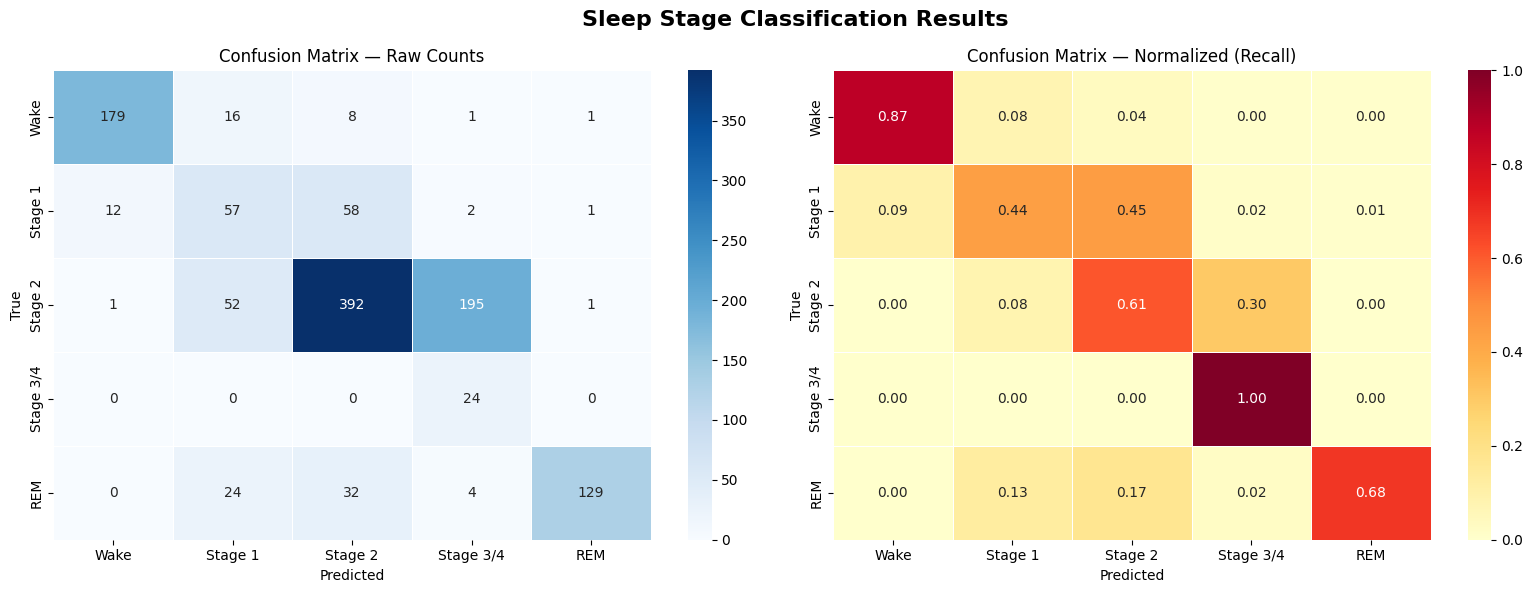

✅ Saved: A_confusion_matrix.png


In [23]:
# Step 10 — Confusion Matrix
plot_confusion_matrix(labels, preds, save_path='A_confusion_matrix.png')

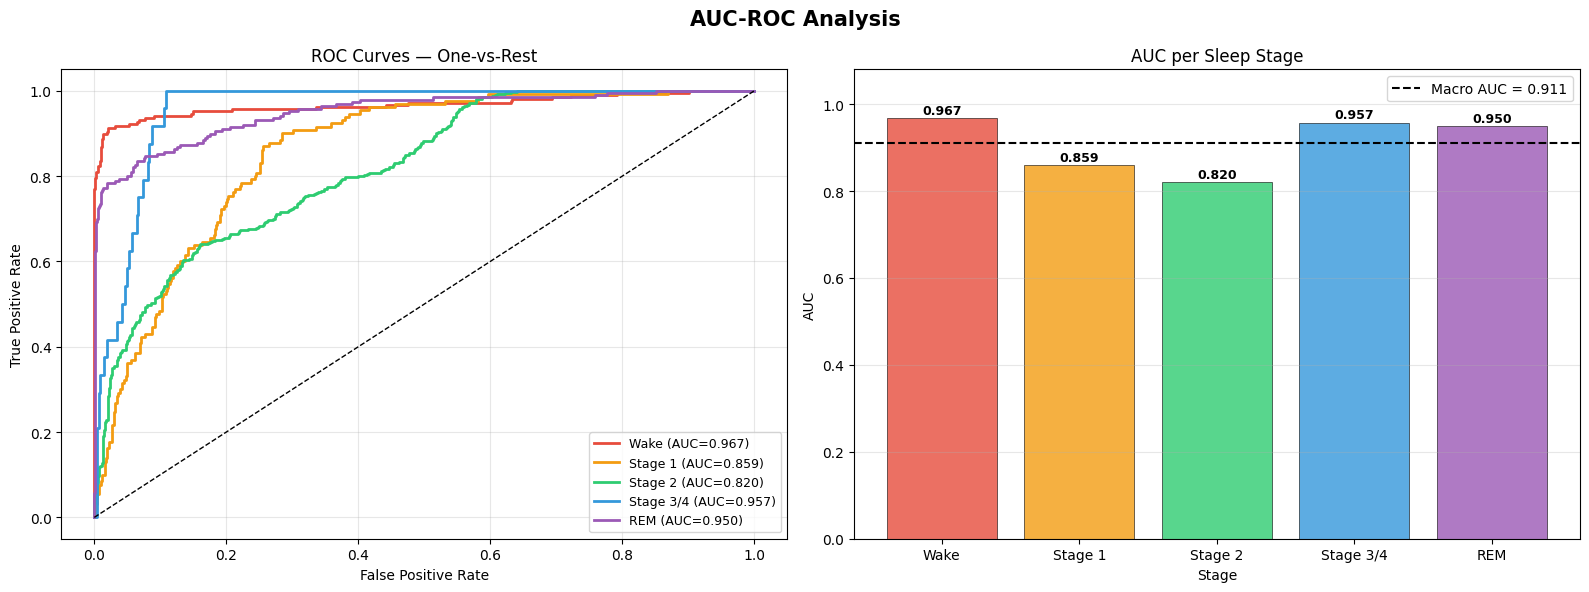

✅ Saved: A_roc_curves.png


In [24]:
# Step 11 — AUC-ROC
plot_roc_curves(labels, probs, save_path='A_roc_curves.png')

✅ Saved: A_hypnogram.png


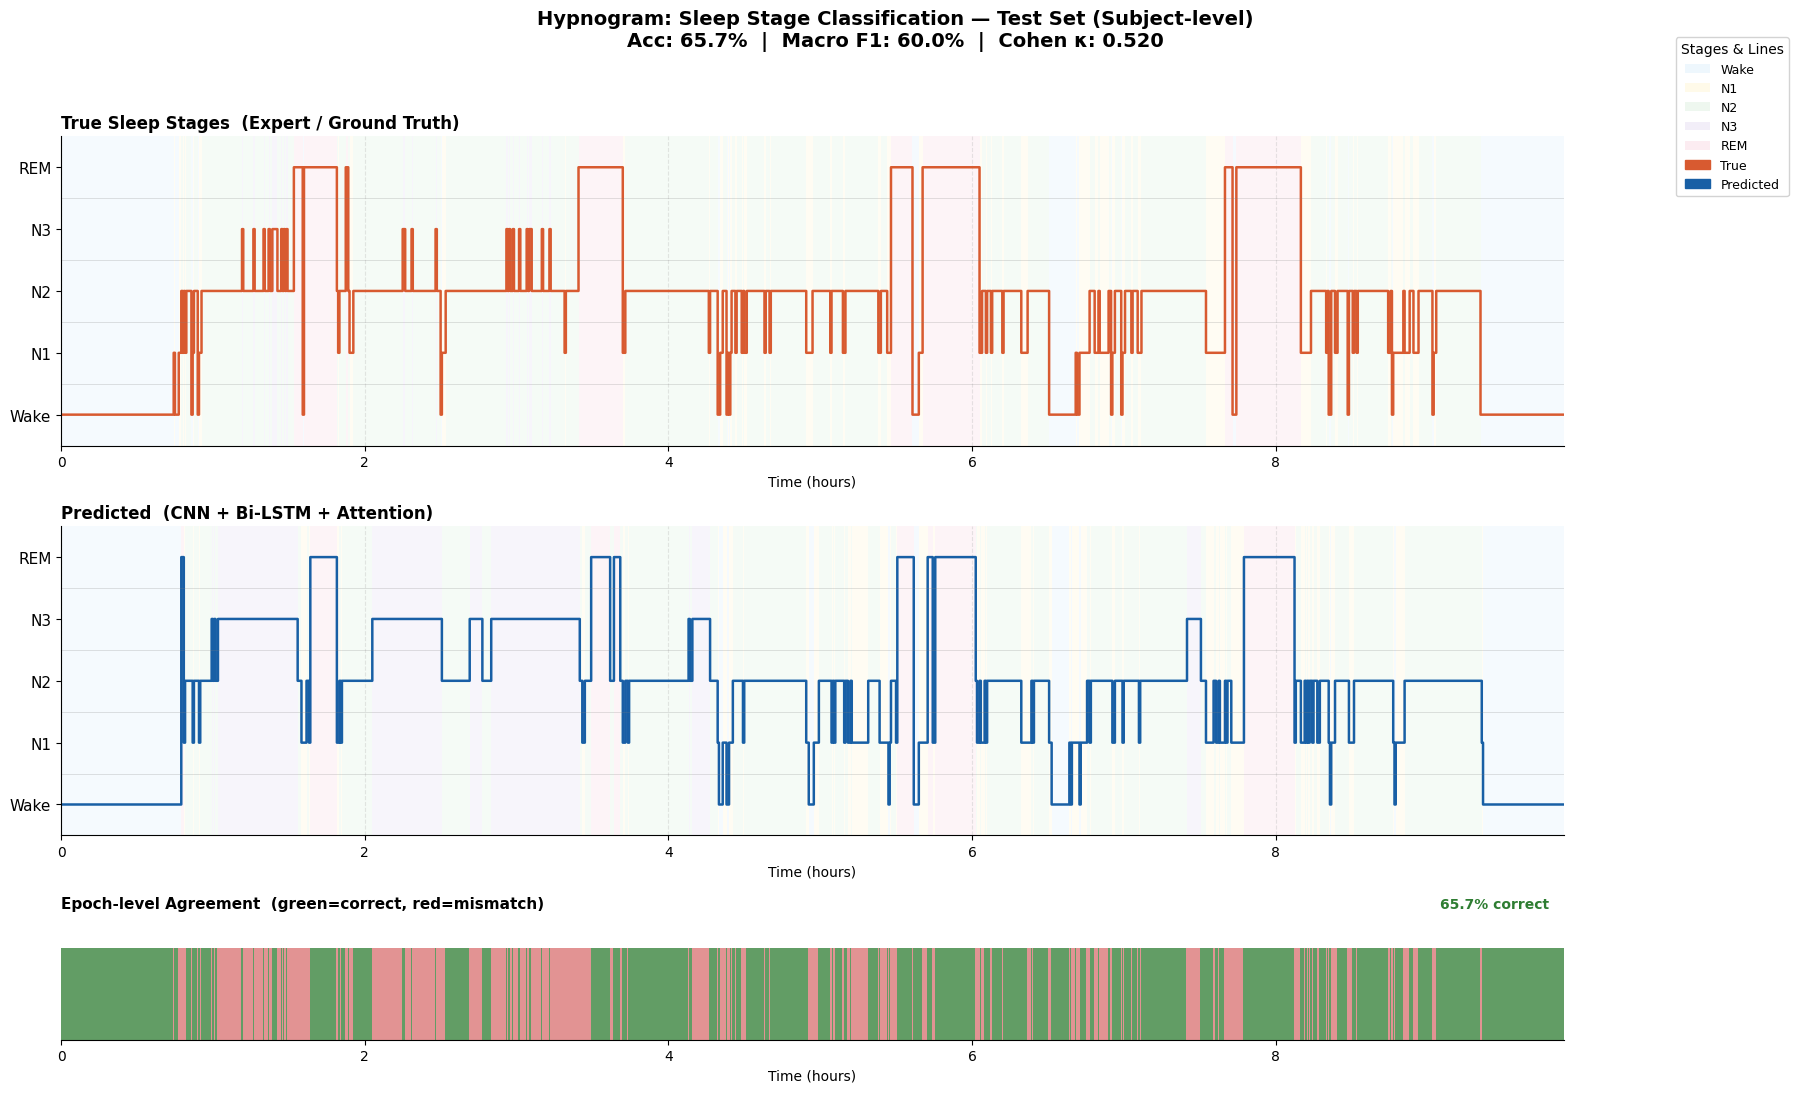

In [25]:
# Step 12 — Hypnogram
plot_hypnogram(preds, labels, subject_id='Test Set (Subject-level)',
               save_path='A_hypnogram.png')